In [183]:
import numpy as np
import matplotlib.pyplot as plt
import firtez_dz as frz
from astropy.io import fits
from matplotlib.colors import CenteredNorm, TwoSlopeNorm
import muram as mio
import matplotlib.colors as colors
from tqdm import tqdm

In [2]:
plt.rc('text', usetex = False)

In [163]:
plt.rc('font', size = 12)

## read files

In [ ]:
# synthesis profiles iter 20000
syn = frz.read_profile('/dat/xenosh/muram_plage_pore/20000/stokes.bin')

In [ ]:
# 26000
syn = frz.read_profile('/dat/xenosh/muram_plage_pore/26000/stokes.bin')

In [266]:
# muram atmosphere iter 20000 ( I only do the binning of stokes profiles at this iter and also some inversions)
sim = frz.read_model('/dat/xenosh/muram_plage_pore/20000/muram_020000_nx1536_ny1536_nz240_d6.bin')

In [66]:
# muram atmosphere iter 26000
sim = frz.read_model('/dat/xenosh/muram_plage_pore/26000/muram_026000_nx1536_ny1536_nz240_d605.bin')

In [6]:
# inversion results of mihi data
atm = fits.open('/dat/xenosh/sharing/new_10s_tau.fits')[0].data
#tau,tem,pg,rho,vmic,vz,bx,by,bz

In [ ]:
# stokes 
stokes = fits.open('/dat/xenosh/MiHi_Fe_I_plage/Time_10s/0/stokes.fits')[0].data

In [98]:
syn_o = frz.read_profile('/dat/xenosh/MiHi_Fe_I_plage/Time_10s/0/c1/MHS/stokes.bin')

In [36]:
ll = fits.open('/dat/xenosh/MiHi_Fe_I_plage/Time_10s/0/stokes.fits')[1].data

In [299]:
# synthesis + bin + inv
sim_inv = frz.read_model('/dat/xenosh/muram_plage_pore/20000/test3/2/out_out_valc_nx192_ny192_nz64_dz12.bin')

In [293]:
sim_inv = frz.read_model('/dat/xenosh/muram_plage_pore/20000/bin_test2/2/out_out_muram_020000_nx192_ny192_nz120_dz12_smooth.bin')

In [67]:
muramdir = '/dat/milic/MURaM_400G_plage_pore/'
time = np.fromfile(muramdir+'2D/Pore_10Mm_6x6km_res_Bz400G_time_012000_to_044450.dat',dtype=np.float64)
nsnaps = time.size //2
time = time.reshape(2,nsnaps)

## interpolate

In [267]:
# interpolate
tau_common = np.linspace(-3,1,41)
nx = sim.tem.shape[0]
ny = sim.tem.shape[1]
nz = tau_common.shape[0]
T= np.zeros((nx,ny,nz))
P= np.zeros((nx,ny,nz))
Bx= np.zeros((nx,ny,nz))
By= np.zeros((nx,ny,nz))
Bz= np.zeros((nx,ny,nz))
Vz= np.zeros((nx,ny,nz))
Bh = np.zeros((nx,ny,nz))
a = np.zeros((nz))
for i in range(nx):
    for j in range(ny):
        T[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.tem[i,j,::-1])
        a = np.interp(tau_common, sim.tau[i,j,::-1], np.log10(sim.pg[i,j,::-1]))
        P[i,j,:] = 10 ** a
        Bx[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.bx[i,j,::-1])
        By[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.by[i,j,::-1])
        Bz[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.bz[i,j,::-1])
        Vz[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.vz[i,j,::-1])
        Bh[i,j,:] = np.sqrt(Bx[i,j,:]**2+By[i,j,:]**2)

In [268]:
B = np.sqrt(Bz**2+Bh**2)

In [269]:
tau_common = tau_common[::-1]
T[:,:,:] = T[:,:,::-1]
P[:,:,:] = P[:,:,::-1]
Bx[:,:,:] = Bx[:,:,::-1]
By[:,:,:] = By[:,:,::-1]
Bz[:,:,:] = Bz[:,:,::-1]
Vz[:,:,:] = Vz[:,:,::-1]
Bh[:,:,:] = Bh[:,:,::-1]
B[:,:,:] = B[:,:,::-1]

In [294]:
# interpolate
tau_common = np.linspace(-3,1,41)
nx = sim_inv.tem.shape[0]
ny = sim_inv.tem.shape[1]
nz = tau_common.shape[0]
#T= np.zeros((nx,ny,nz))
#P= np.zeros((nx,ny,nz))
Bx1= np.zeros((nx,ny,nz))
By1= np.zeros((nx,ny,nz))
Bz1= np.zeros((nx,ny,nz))
#Vz= np.zeros((nx,ny,nz))
#Bh = np.zeros((nx,ny,nz))
#a = np.zeros((nz))
for i in range(nx):
    for j in range(ny):
        #T[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.tem[i,j,::-1])
        #a = np.interp(tau_common, sim.tau[i,j,::-1], np.log10(sim.pg[i,j,::-1]))
        #P[i,j,:] = 10 ** a
        Bx1[i,j,:] = np.interp(tau_common, sim_inv.tau[i,j,::-1], sim_inv.bx[i,j,::-1])
        By1[i,j,:] = np.interp(tau_common, sim_inv.tau[i,j,::-1], sim_inv.by[i,j,::-1])
        Bz1[i,j,:] = np.interp(tau_common, sim_inv.tau[i,j,::-1], sim_inv.bz[i,j,::-1])
        #Vz[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.vz[i,j,::-1])
        #Bh[i,j,:] = np.sqrt(Bx[i,j,:]**2+By[i,j,:]**2)
        

In [295]:
B1 = np.sqrt(Bz1**2+Bx1**2+By1**2)

In [296]:
tau_common = tau_common[::-1]
Bx1[:,:,:] = Bx1[:,:,::-1]
By1[:,:,:] = By1[:,:,::-1]
Bz1[:,:,:] = Bz1[:,:,::-1]
B1[:,:,:] = B1[:,:,::-1]

In [300]:
# interpolate
tau_common = np.linspace(-3,1,41)
nx = sim_inv.tem.shape[0]
ny = sim_inv.tem.shape[1]
nz = tau_common.shape[0]
#T= np.zeros((nx,ny,nz))
#P= np.zeros((nx,ny,nz))
#Bx1= np.zeros((nx,ny,nz))
#By1= np.zeros((nx,ny,nz))
Bz2= np.zeros((nx,ny,nz))
#Vz= np.zeros((nx,ny,nz))
#Bh = np.zeros((nx,ny,nz))
#a = np.zeros((nz))
for i in range(nx):
    for j in range(ny):
        #T[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.tem[i,j,::-1])
        #a = np.interp(tau_common, sim.tau[i,j,::-1], np.log10(sim.pg[i,j,::-1]))
        #P[i,j,:] = 10 ** a
        #Bx1[i,j,:] = np.interp(tau_common, sim_inv.tau[i,j,::-1], sim_inv.bx[i,j,::-1])
        #By1[i,j,:] = np.interp(tau_common, sim_inv.tau[i,j,::-1], sim_inv.by[i,j,::-1])
        Bz2[i,j,:] = np.interp(tau_common, sim_inv.tau[i,j,::-1], sim_inv.bz[i,j,::-1])
        #Vz[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.vz[i,j,::-1])
        #Bh[i,j,:] = np.sqrt(Bx[i,j,:]**2+By[i,j,:]**2)
Bz2[:,:,:] = Bz2[:,:,::-1]

## FoV

In [274]:
Bz_bin = Bz.reshape(1536//8,8,1536//8,8,41).mean(axis=(1,3))
B_bin = B.reshape(1536//8,8,1536//8,8,41).mean(axis=(1,3))

In [82]:
stack = np.concatenate([Bz[:,:,:], Bz[:,:,:]],axis=1)
stack_bin = np.concatenate([Bz_bin[:,:,:], Bz_bin[:,:,:]],axis=1)

In [83]:
B_stacked = np.concatenate([B[:,:,:], B[:,:,:]],axis=1)
B_stacked_bin = np.concatenate([B_bin[:,:,:], B_bin[:,:,:]],axis=1)

In [165]:
#position of the select pixels
# in obs
x1, y1 = 47, 12
x2, y2 = 52, 54
# in sim
x3, y3 = 1014, 778
x4, y4 = 1012, 934

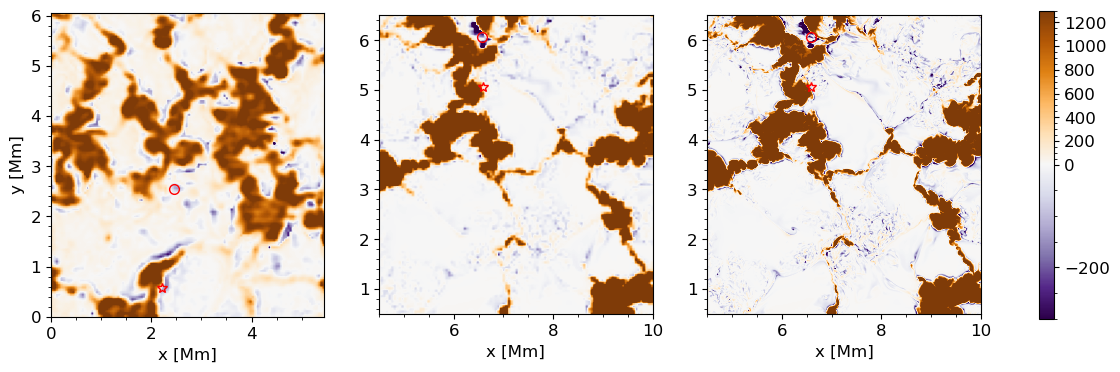

In [84]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(atm[0,8,:,:,15].T,origin='lower',cmap='PuOr',norm=TwoSlopeNorm(vmax=300,vcenter=0,vmin=-1300),extent=[0,116*0.047,0,129*0.047])
#plt.colorbar()
#plt.contour(atm[0,8,:,:,15].T,levels=[50],extent=[0,116*0.047,0,129*0.047])
plt.plot(x1*0.047,y1*0.047,marker='*',c='red',markersize=7,fillstyle='none')
plt.plot(x2*0.047,y2*0.047,marker='o',c='red',markersize=7,fillstyle='none')
plt.xlabel('x [Mm]')
plt.ylabel('y [Mm]')
plt.subplot(132)
plt.imshow(stack_bin[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,10,0,20])
#plt.colorbar()
plt.xlim([4.5,10])
plt.ylim([0.5,6.5])
plt.xlabel('x [Mm]')
#plt.ylabel('y [Mm]')
#plt.contour(stack_bin[:,:,15],levels=[-50],extent=[0,20,0,10])
plt.plot(x3*0.0065,y3*0.0065,marker='*',c='red',markersize=7,fillstyle='none')
plt.plot(x4*0.0065,y4*0.0065,marker='o',c='red',markersize=7,fillstyle='none')
plt.subplot(133)
im=plt.imshow(stack[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,10,0,20])
#plt.colorbar()
cbar = plt.colorbar(im,ax=plt.gcf().get_axes(),location='right',shrink=0.8)
plt.xlim([4.5,10])
plt.ylim([0.5,6.5])
plt.xlabel('x [Mm]')
#plt.ylabel('y [Mm]')
#plt.contour(stack[:,:,15],levels=[-50],extent=[0,20,0,10])
plt.plot(x3*0.0065,y3*0.0065,marker='*',c='red',markersize=7,fillstyle='none')
plt.plot(x4*0.0065,y4*0.0065,marker='o',c='red',markersize=7,fillstyle='none')
#plt.tight_layout()
#plt.savefig('Bz_oppo.eps',bbox_inches='tight')

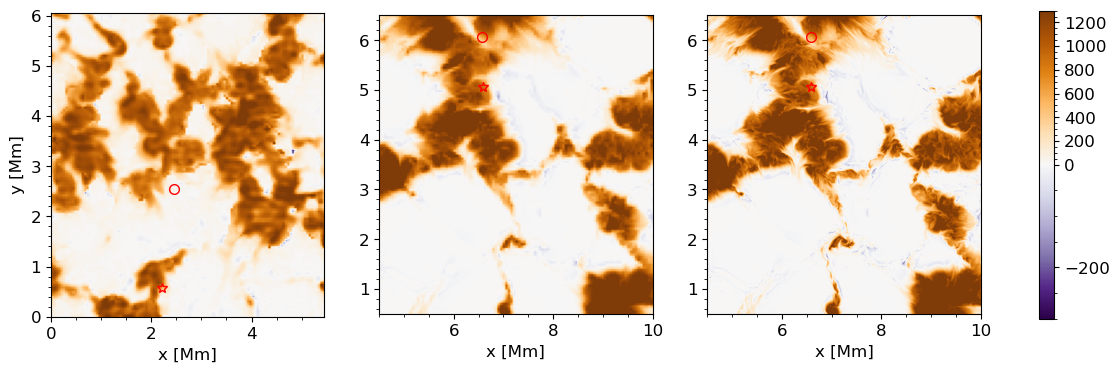

In [166]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(atm[0,8,:,:,30].T,origin='lower',cmap='PuOr',norm=TwoSlopeNorm(vmax=300,vcenter=0,vmin=-1300),extent=[0,116*0.047,0,129*0.047])
#plt.colorbar()
#plt.contour(atm[0,8,:,:,15].T,levels=[50],extent=[0,116*0.047,0,129*0.047])
plt.plot(x1*0.047,y1*0.047,marker='*',c='red',markersize=7,fillstyle='none')
plt.plot(x2*0.047,y2*0.047,marker='o',c='red',markersize=7,fillstyle='none')
plt.xlabel('x [Mm]')
plt.ylabel('y [Mm]')
plt.subplot(132)
plt.imshow(stack_bin[:,:,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,10,0,20])
#plt.colorbar()
plt.xlim([4.5,10])
plt.ylim([0.5,6.5])
plt.xlabel('x [Mm]')
#plt.ylabel('y [Mm]')
#plt.contour(stack_bin[:,:,15],levels=[-50],extent=[0,20,0,10])
plt.plot(x3*0.0065,y3*0.0065,marker='*',c='red',markersize=7,fillstyle='none')
plt.plot(x4*0.0065,y4*0.0065,marker='o',c='red',markersize=7,fillstyle='none')
plt.subplot(133)
im=plt.imshow(stack[:,:,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmax=1300,vcenter=0,vmin=-300),extent=[0,10,0,20])
#plt.colorbar()
cbar = plt.colorbar(im,ax=plt.gcf().get_axes(),location='right',shrink=0.8)
plt.xlim([4.5,10])
plt.ylim([0.5,6.5])
plt.xlabel('x [Mm]')
#plt.ylabel('y [Mm]')
#plt.contour(stack[:,:,15],levels=[-50],extent=[0,20,0,10])
plt.plot(x3*0.0065,y3*0.0065,marker='*',c='red',markersize=7,fillstyle='none')
plt.plot(x4*0.0065,y4*0.0065,marker='o',c='red',markersize=7,fillstyle='none')
#plt.tight_layout()
#plt.savefig('Bz_oppo.eps',bbox_inches='tight')

## example Stokes profiles

In [142]:
plt.rc('font', size = 18)

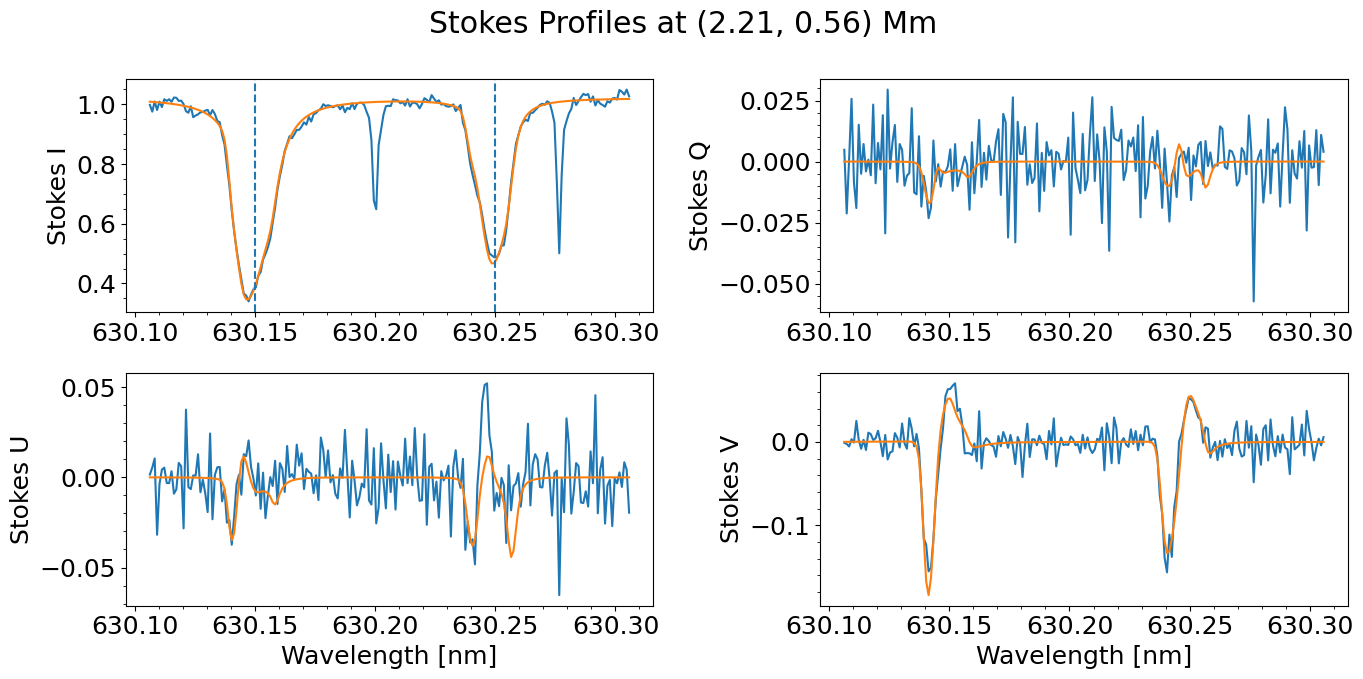

In [ ]:
ix, iy = x1, y1
x, y = ix*0.047, iy*0.047
plt.figure(figsize=(14,7))
plt.subplot(221)
plt.plot(ll/10, stokes[ix, iy, 0, :])
plt.plot(ll/10, syn_o.stki[:, ix, iy])
plt.axvline(630.15,ls='--')
plt.axvline(630.25,ls='--')
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes I')
#plt.xlabel('Wavelength [nm]')
plt.subplot(222)
plt.plot(ll/10, stokes[ix, iy, 1, :])
plt.plot(ll/10, syn_o.stkq[:, ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes Q')
#plt.xlabel('Wavelength [nm]')
plt.subplot(223)
plt.plot(ll/10, stokes[ix, iy, 2, :])
plt.plot(ll/10, syn_o.stku[:, ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes U')
plt.xlabel('Wavelength [nm]')
plt.subplot(224)
plt.plot(ll/10, stokes[ix, iy, 3, :])
plt.plot(ll/10, syn_o.stkv[:, ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes V')
plt.xlabel('Wavelength [nm]')
plt.suptitle(f'Stokes Profiles at ({x:.2f}, {y:.2f}) Mm')
plt.tight_layout()
#plt.savefig('stk_obs1.eps',bbox_inches='tight')
#plt.savefig('stk_obs1.png',bbox_inches='tight')

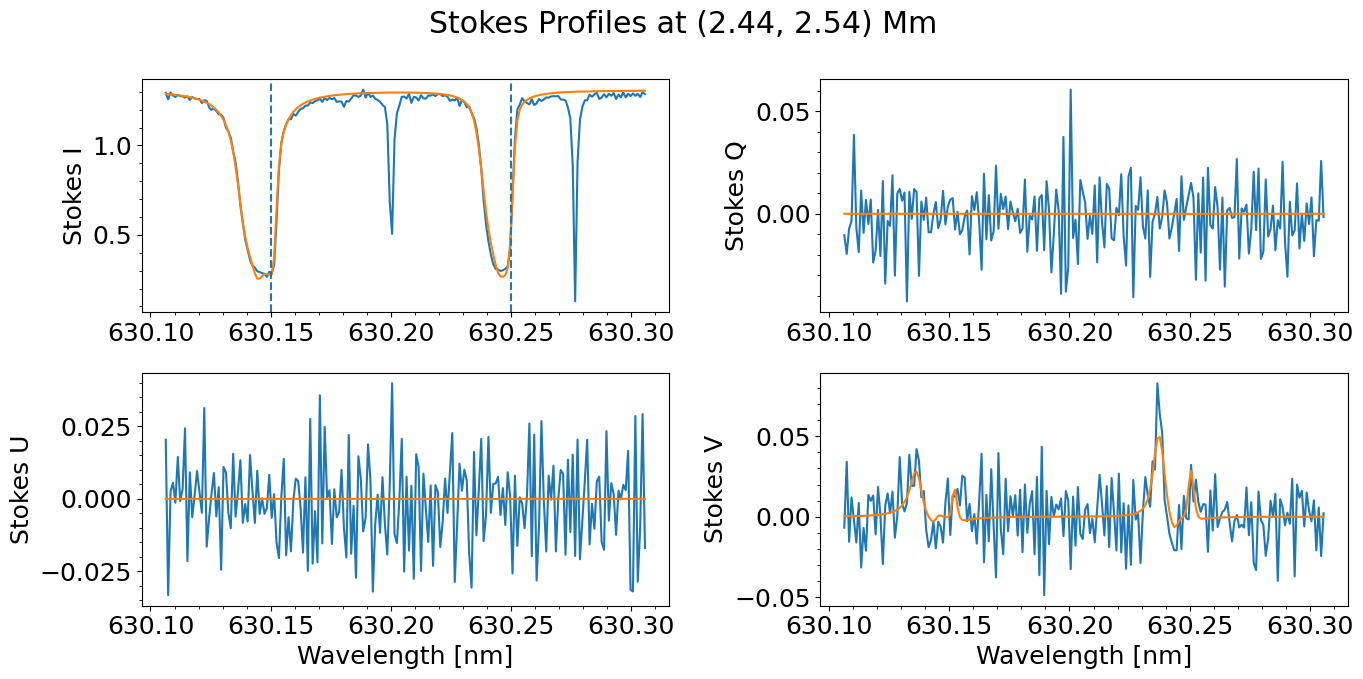

In [ ]:
ix, iy = x2, y2
x, y = ix*0.047, iy*0.047
plt.figure(figsize=(14,7))
plt.subplot(221)
plt.plot(ll/10, stokes[ix, iy, 0, :])
plt.plot(ll/10, syn_o.stki[:, ix, iy])
plt.axvline(630.15,ls='--')
plt.axvline(630.25,ls='--')
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes I')
#plt.xlabel('Wavelength [nm]')
plt.subplot(222)
plt.plot(ll/10, stokes[ix, iy, 1, :])
plt.plot(ll/10, syn_o.stkq[:, ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes Q')
#plt.xlabel('Wavelength [nm]')
plt.subplot(223)
plt.plot(ll/10, stokes[ix, iy, 2, :])
plt.plot(ll/10, syn_o.stku[:, ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes U')
plt.xlabel('Wavelength [nm]')
plt.subplot(224)
plt.plot(ll/10, stokes[ix, iy, 3, :])
plt.plot(ll/10, syn_o.stkv[:, ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes V')
plt.xlabel('Wavelength [nm]')
plt.suptitle(f'Stokes Profiles at ({x:.2f}, {y:.2f}) Mm')
plt.tight_layout()
#plt.savefig('stk_obs2.eps',bbox_inches='tight')
#plt.savefig('stk_obs2.png',bbox_inches='tight')

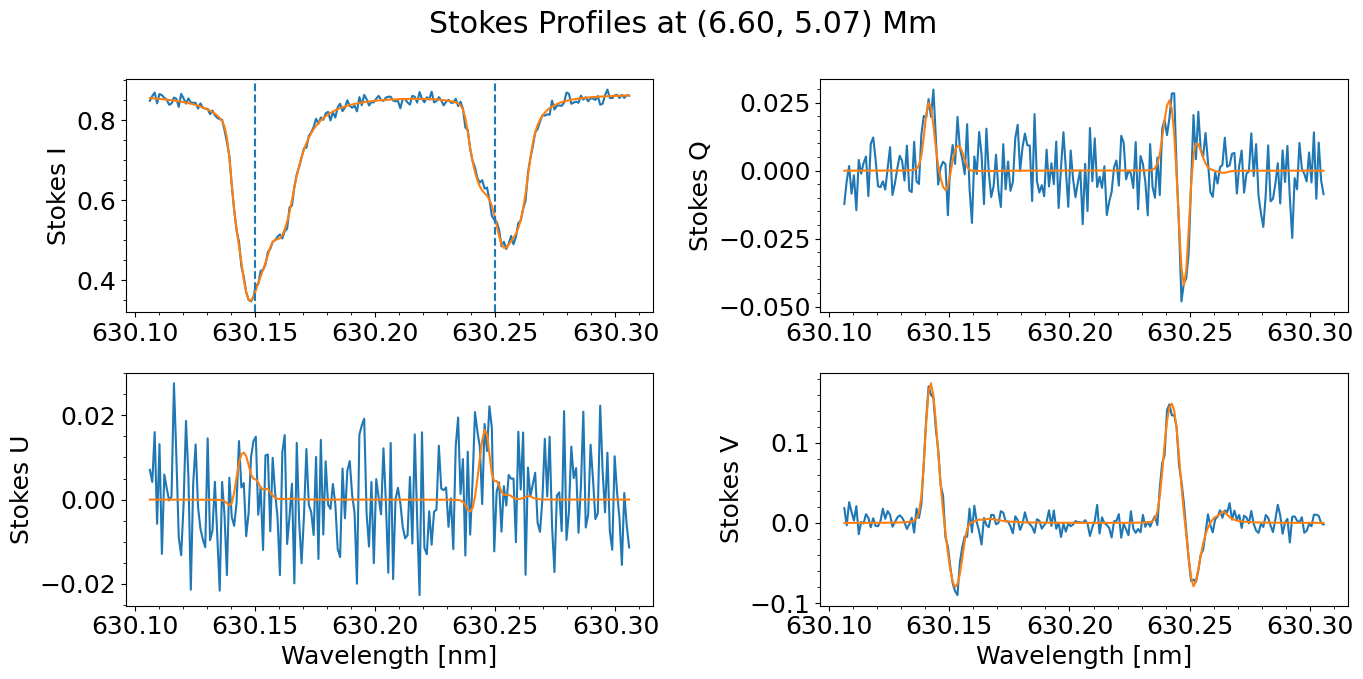

In [ ]:
ix, iy = x3, y3
x, y = ix/1536*10, iy/1536*10
plt.figure(figsize=(14,7))
plt.subplot(221)
plt.plot(ll/10, syn.stki[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
plt.plot(ll/10, syn.stki[:,ix, iy])
plt.axvline(630.15,ls='--')
plt.axvline(630.25,ls='--')
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes I')
#plt.xlabel('Wavelength [nm]')
plt.subplot(222)
plt.plot(ll/10, syn.stkq[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
plt.plot(ll/10, syn.stkq[:,ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes Q')
#plt.xlabel('Wavelength [nm]')
plt.subplot(223)
plt.plot(ll/10, syn.stku[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
plt.plot(ll/10, syn.stku[:,ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes U')
plt.xlabel('Wavelength [nm]')
plt.subplot(224)
plt.plot(ll/10, syn.stkv[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
plt.plot(ll/10, syn.stkv[:,ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes V')
plt.xlabel('Wavelength [nm]')
plt.suptitle(f'Stokes Profiles at ({x:.2f}, {y:.2f}) Mm')
plt.tight_layout()
#plt.savefig('stk_sim1.eps',bbox_inches='tight')
#plt.savefig('stk_sim1.png',bbox_inches='tight')

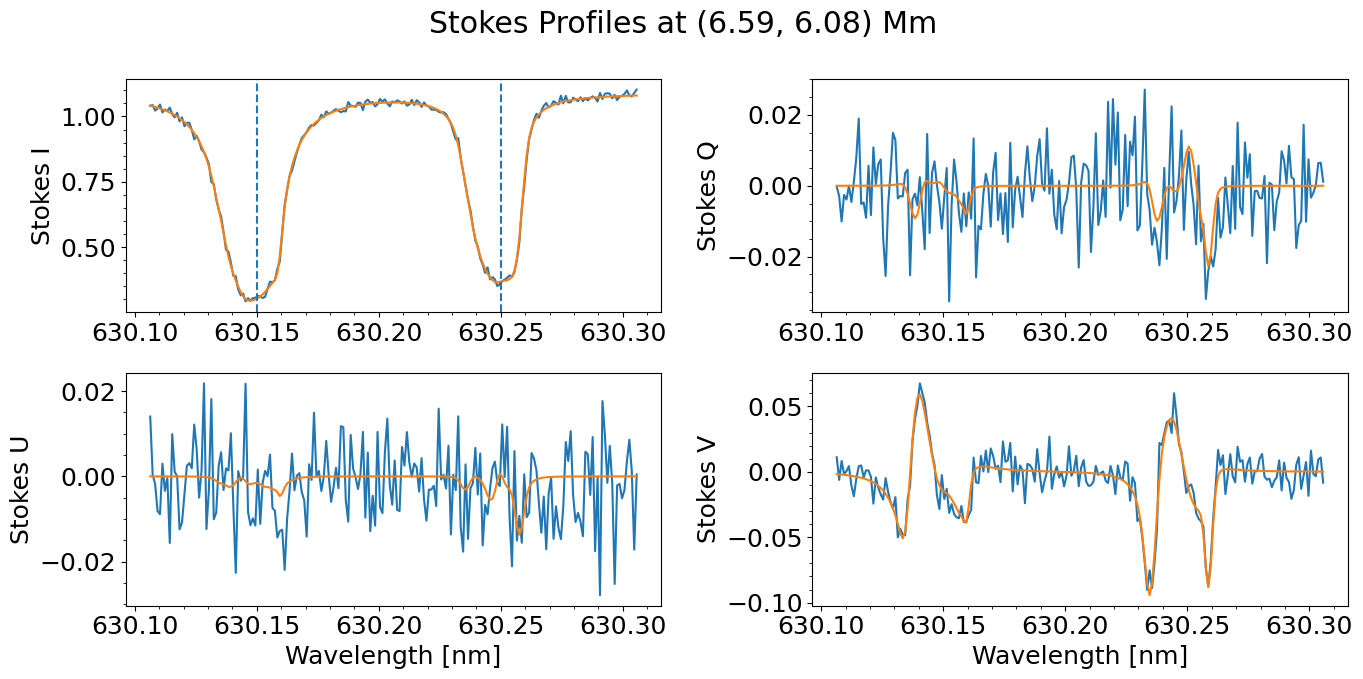

In [ ]:
ix, iy = x4, y4
x, y = ix/1536*10, iy/1536*10
plt.figure(figsize=(14,7))
plt.subplot(221)
plt.plot(ll/10, syn.stki[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
plt.plot(ll/10, syn.stki[:,ix, iy])
plt.axvline(630.15,ls='--')
plt.axvline(630.25,ls='--')
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes I')
#plt.xlabel('Wavelength [nm]')
plt.subplot(222)
plt.plot(ll/10, syn.stkq[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
plt.plot(ll/10, syn.stkq[:,ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes Q')
#plt.xlabel('Wavelength [nm]')
plt.subplot(223)
plt.plot(ll/10, syn.stku[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
plt.plot(ll/10, syn.stku[:,ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes U')
plt.xlabel('Wavelength [nm]')
plt.subplot(224)
plt.plot(ll/10, syn.stkv[:,ix, iy]+ np.random.normal(loc=0, scale=1e-2,size=(200,)))
plt.plot(ll/10, syn.stkv[:,ix, iy])
plt.xticks([630.10,630.15,630.20,630.25,630.30])
plt.ylabel('Stokes V')
plt.xlabel('Wavelength [nm]')
plt.suptitle(f'Stokes Profiles at ({x:.2f}, {y:.2f}) Mm')
plt.tight_layout()
#plt.savefig('stk_sim2.eps',bbox_inches='tight')
#plt.savefig('stk_sim2.png',bbox_inches='tight')

## define opposite pixels

In [ ]:
# sim

In [306]:
x1 = int(4.5/10*1536)
x2 = int(10/10*1536)

In [307]:
y1 = int(0.5/10*1536)
y2 = int(6.5/10*1536)

In [ ]:
c1 = B[:,:,10]>1000
c2 = B[:,:,10]<100
core = np.argwhere(c1)
qs = np.argwhere(c2)

In [ ]:
c3 = B[:,:,30] > 300
c4 = B[:,:,30] - B[:,:,10] > 50
c5 = B[:,:,10] < 1000
canopy = np.argwhere(c5 & c3 & c4)

In [125]:
c6 = Bz[x1:x2,y1:y2,15] < -50
c7 = B[x1:x2,y1:y2,30] > 300
oppo = np.argwhere(c6 & c7)

In [178]:
c8 = B[x1:x2,y1:y2,30] > 200
plage = np.argwhere(c8)

In [179]:
c8 = B_bin[x1//8:x2//8,y1//8:y2//8,30] > 200
plage_bin = np.argwhere(c8)

In [ ]:
print(qs.shape)
print(core.shape)
print(canopy.shape)
print(oppo.shape)

In [ ]:
# obs inv

In [130]:
t = 20

In [ ]:
c1 = np.sqrt(atm[t,6,:,:,10]**2+atm[t,7,:,:,10]**2+atm[t,8,:,:,10]**2)>900
c2 = np.sqrt(atm[t,6,:,:,10]**2+atm[t,7,:,:,10]**2+atm[t,8,:,:,10]**2)<200
core_o = np.argwhere(c1)
qs_o = np.argwhere(c2)

In [ ]:
c3 = np.sqrt(atm[t,6,:,:,30]**2+atm[t,7,:,:,30]**2+atm[t,8,:,:,30]**2) > 300
c4 = np.sqrt(atm[t,6,:,:,30]**2+atm[t,7,:,:,30]**2+atm[t,8,:,:,30]**2) - np.sqrt(atm[1,6,:,:,10]**2+atm[1,7,:,:,10]**2+atm[1,8,:,:,10]**2) > 50
c5 = np.sqrt(atm[t,6,:,:,10]**2+atm[t,7,:,:,10]**2+atm[t,8,:,:,10]**2) < 1000
canopy_o = np.argwhere(c5 & c3 & c4)

In [176]:
c6 = atm[t,8,:,:,15] > 50
c7 = np.sqrt(atm[t,6,:,:,30]**2+atm[t,7,:,:,30]**2+atm[t,8,:,:,30]**2) > 200
oppo_o = np.argwhere(c6 & c7)

In [177]:
plage_o = np.argwhere(c7)

In [ ]:
print(qs_o.shape)
print(core_o.shape)
print(canopy_o.shape)
print(oppo_o.shape)

## hist bz

In [171]:
plt.rc('font', size = 16)

In [ ]:
# hist bz of 'plage' region where |B|>300 G

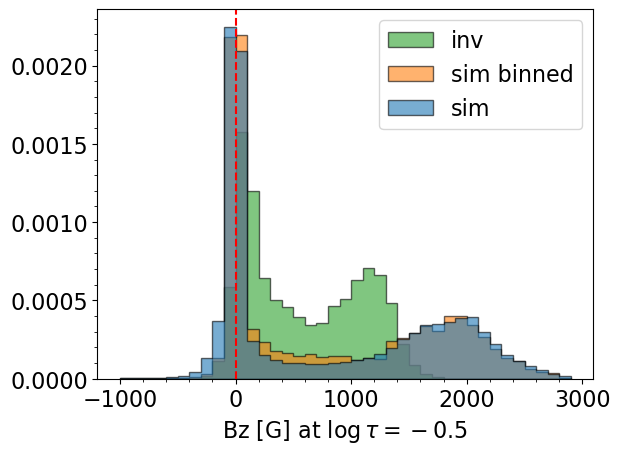

In [180]:
xbins = np.arange(-1000,3000,100)
plt.hist([Bz[plage[:,0]+x1,plage[:,1]+y1,15].flatten(),Bz_bin[plage_bin[:,0]+x1//8,plage_bin[:,1]+y1//8,15],-atm[20,8,plage_o[:,0],plage_o[:,1],15]],bins=xbins,histtype='stepfilled',alpha=0.6,label=['sim','sim binned','inv'],
            density = [[1/plage.shape[0]]*plage.shape[0],[1/plage_bin.shape[0]]*plage_bin.shape[0],[1/plage_o.shape[0]]*plage_o.shape[0]], edgecolor='black')
plt.legend()
plt.xlabel(r'Bz [G] at $\log\tau=-0.5$')
plt.axvline(0,color='red',ls='--')
#plt.savefig('hist_bz.png',bbox_inches='tight')

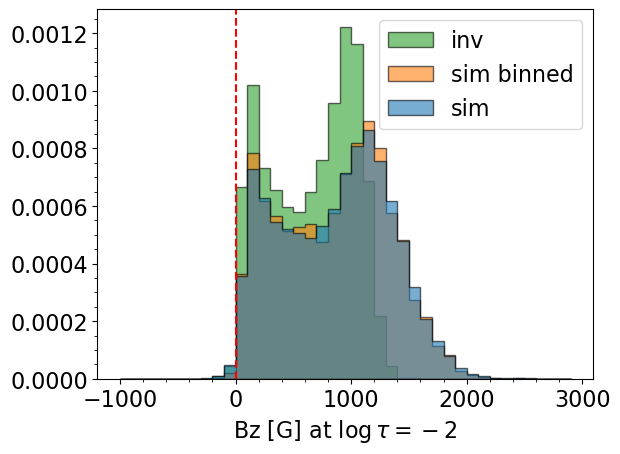

In [181]:
xbins = np.arange(-1000,3000,100)
plt.hist([Bz[plage[:,0]+x1,plage[:,1]+y1,30].flatten(),Bz_bin[plage_bin[:,0]+x1//8,plage_bin[:,1]+y1//8,30],-atm[20,8,plage_o[:,0],plage_o[:,1],30]],bins=xbins,histtype='stepfilled',alpha=0.6,label=['sim','sim binned','inv'],
            density = [[1/plage.shape[0]]*plage.shape[0],[1/plage_bin.shape[0]]*plage_bin.shape[0],[1/plage_o.shape[0]]*plage_o.shape[0]], edgecolor='black')
plt.legend()
plt.xlabel(r'Bz [G] at $\log\tau=-2$')
plt.axvline(0,color='red',ls='--')
#plt.savefig('hist_bz2.png',bbox_inches='tight')

In [ ]:
# hist bz of FoV

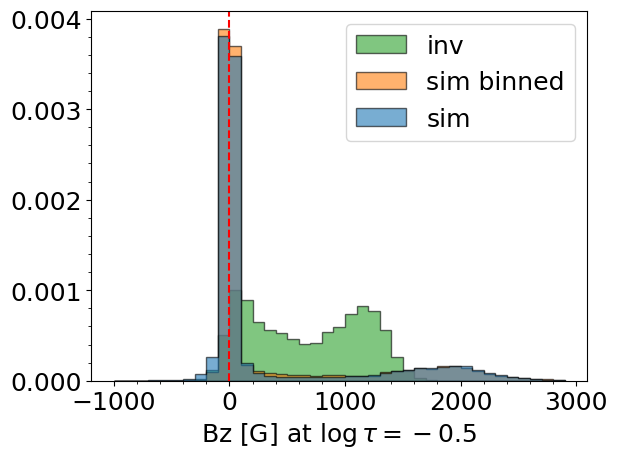

In [155]:
xbins = np.arange(-1000,3000,100)
plt.hist([Bz[x1:x2,y1:y2,15].flatten(),Bz_bin[x1//8:x2//8,y1//8:y2//8,15].flatten(),-atm[20,8,plage_o[:,0],plage_o[:,1],15]],bins=xbins,histtype='stepfilled',alpha=0.6,label=['sim','sim binned','inv'],
            density = [[1/((x2-x1)*(y2-y1))]*((x2-x1)*(y2-y1)),[1/((x2//8-x1//8)*(y2//8-y1//8))]*((x2//8-x1//8)*(y2//8-y1//8)),[1/plage_o.shape[0]]*plage_o.shape[0]], edgecolor='black')
plt.legend()
plt.xlabel(r'Bz [G] at $\log\tau=-0.5$')
plt.axvline(0,color='red',ls='--')
#plt.savefig('hist_bz.png',bbox_inches='tight')

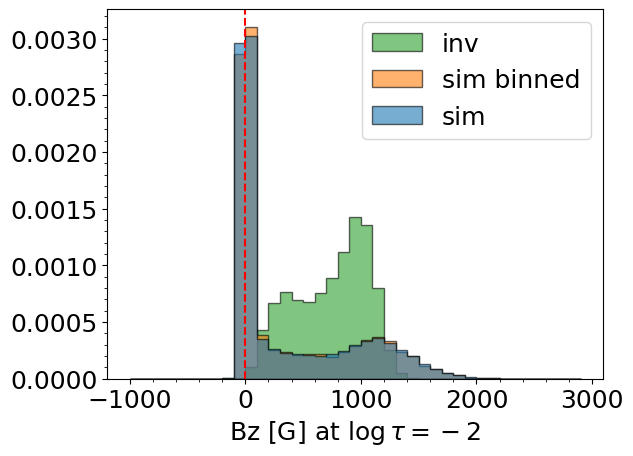

In [162]:
xbins = np.arange(-1000,3000,100)
plt.hist([Bz[x1:x2,y1:y2,30].flatten(),Bz_bin[x1//8:x2//8,y1//8:y2//8,30].flatten(),-atm[20,8,plage_o[:,0],plage_o[:,1],30]],bins=xbins,histtype='stepfilled',alpha=0.6,label=['sim','sim binned','inv'],
            density = [[1/((x2-x1)*(y2-y1))]*((x2-x1)*(y2-y1)),[1/((x2//8-x1//8)*(y2//8-y1//8))]*((x2//8-x1//8)*(y2//8-y1//8)),[1/plage_o.shape[0]]*plage_o.shape[0]], edgecolor='black')
plt.legend()
plt.xlabel(r'Bz [G] at $\log\tau=-2$')
plt.axvline(0,color='red',ls='--')
#plt.savefig('hist_bz2.png',bbox_inches='tight')

## fraction of oppo

In [185]:
oppo_counts = []
Bz_o_mean = []
for t in tqdm(range(145)):
    c6 = atm[t,8,:,:,10] > 50
    c7 = atm[t,8,:,:,30] <-200
    #c7 = np.sqrt(atm[t,8,:,:,30]**2+atm[t,6,:,:,30]**2+atm[t,7,:,:,30]**2) > 300
    oppo_o = np.argwhere(c6 & c7)
    oppo_counts.append(oppo_o.shape[0])
    Bz_o_mean.append(np.mean(atm[t,8,oppo_o[:,0],oppo_o[:,1],10]))
oppo_counts = np.array(oppo_counts)

100%|██████████| 145/145 [00:00<00:00, 374.78it/s]


In [186]:
to = np.arange(145)*10

In [187]:
nx = 1536
ny = 1536
nz = 1056
nsnaps = 650

In [188]:
Bz0 = np.memmap(muramdir+'2D/Pore_10Mm_6x6km_res_Bz400G_tau_1.000_bx_012000_to_044450.dat',dtype=np.float32,mode='r',shape=(nsnaps,nx,ny))
Bz1 = np.memmap(muramdir+'2D/Pore_10Mm_6x6km_res_Bz400G_tau_0.100_bx_012000_to_044450.dat',dtype=np.float32,mode='r',shape=(nsnaps,nx,ny))
Bz2 = np.memmap(muramdir+'2D/Pore_10Mm_6x6km_res_Bz400G_tau_0.010_bx_012000_to_044450.dat',dtype=np.float32,mode='r',shape=(nsnaps,nx,ny))

In [189]:
Bz0_bin = Bz0.reshape(650,1536//8,8,1536//8,8).mean(axis=(2,4))
Bz2_bin = Bz2.reshape(650,1536//8,8,1536//8,8).mean(axis=(2,4))

In [190]:
oppo_s_counts = [] 
Bz_s_mean = []
for t in tqdm(range(650)):
    c6 = Bz0[t,:,:]*np.sqrt(4*np.pi) < -50
    c7 = Bz2[t,:,:]*np.sqrt(4*np.pi) > 200
    oppo = np.argwhere(c6 & c7)
    oppo_s_counts.append(oppo.shape[0])
    Bz_s_mean.append(np.mean(Bz0[t,oppo[:,0],oppo[:,1]]))
oppo_s_counts = np.array(oppo_s_counts)

100%|██████████| 650/650 [00:07<00:00, 86.06it/s]


In [191]:
oppo_sb_counts = [] 
Bz_sb_mean = []
for t in tqdm(range(650)):
    c6 = Bz0_bin[t,:,:]*np.sqrt(4*np.pi) < -50
    c7 = Bz2_bin[t,:,:]*np.sqrt(4*np.pi) > 200
    oppo = np.argwhere(c6 & c7)
    oppo_sb_counts.append(oppo.shape[0])
    Bz_sb_mean.append(np.mean(Bz0_bin[t,oppo[:,0],oppo[:,1]]))
oppo_sb_counts = np.array(oppo_sb_counts)

100%|██████████| 650/650 [00:00<00:00, 5478.41it/s]


In [192]:
ts = np.arange(650)*1.43

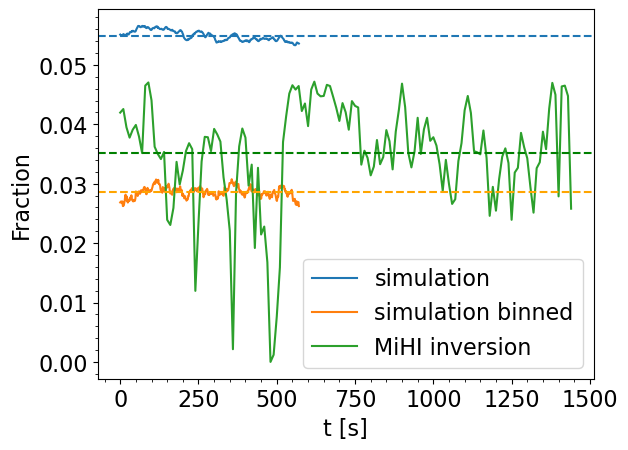

In [194]:
plt.plot(ts[:400],oppo_s_counts[:400]/1536./1536.,label='simulation')
plt.plot(ts[:400],oppo_sb_counts[:400]/192./192.,label='simulation binned')
plt.plot(to,oppo_counts/129./116.,label='MiHI inversion')
plt.xlabel('t [s]')
plt.ylabel('Fraction')
plt.axhline(np.mean(oppo_s_counts[:400])/1536/1536,ls='--')
plt.axhline(np.mean(oppo_sb_counts[:400])/192/192,ls='--',color='orange')
plt.axhline(np.mean(oppo_counts)/129/116,ls='--',color='green')
plt.legend()

In [195]:
print(np.mean(oppo_s_counts[:400])/1536/1536)
print(np.mean(oppo_sb_counts[:400])/192/192)
print(np.mean(oppo_counts)/129/116)

0.05494690259297689
0.028567979600694446
0.035138585478712125


In [196]:
del(Bz0, Bz1, Bz2, Bz0_bin, Bz2_bin)

## event of oppo

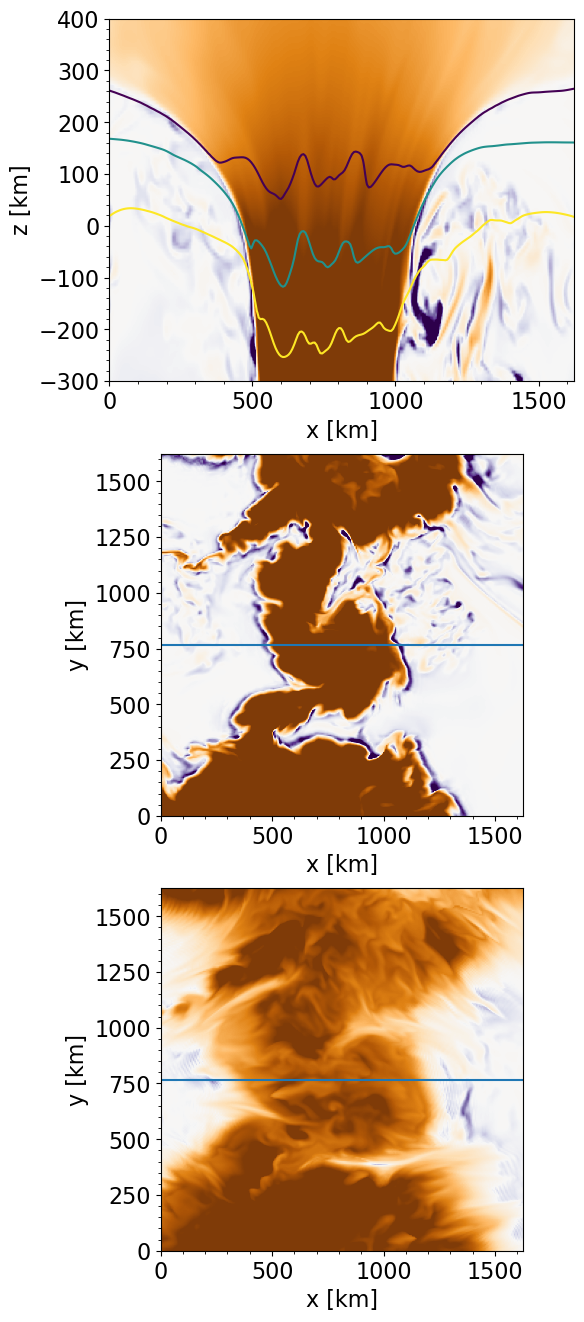

In [235]:
plt.figure(figsize=(6,16))
plt.subplot(311)
plt.imshow(sim.bz[850:1100,768,50:200].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300),extent=[0,250*6.5,-60*6.5,(150-60)*6.5],aspect='auto')
plt.contour(sim.tau[850:1100,768,50:200].T,levels=['-2','-1','0'],extent=[0,250*6.5,-60*6.5,(150-60)*6.5])
plt.ylim([-300,400])
plt.ylabel('z [km]')
plt.xlabel('x [km]')
plt.subplot(312)
plt.imshow(Bz[850:1100,650:900,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300),extent=[0,250*6.5,0,250*6.5])
plt.ylabel('y [km]')
plt.xlabel('x [km]')
plt.axhline((768-650)*6.5)
plt.subplot(313)
plt.imshow(Bz[850:1100,650:900,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300),extent=[0,250*6.5,0,250*6.5])
plt.ylabel('y [km]')
plt.xlabel('x [km]')
plt.axhline((768-650)*6.5)
#plt.tight_layout()

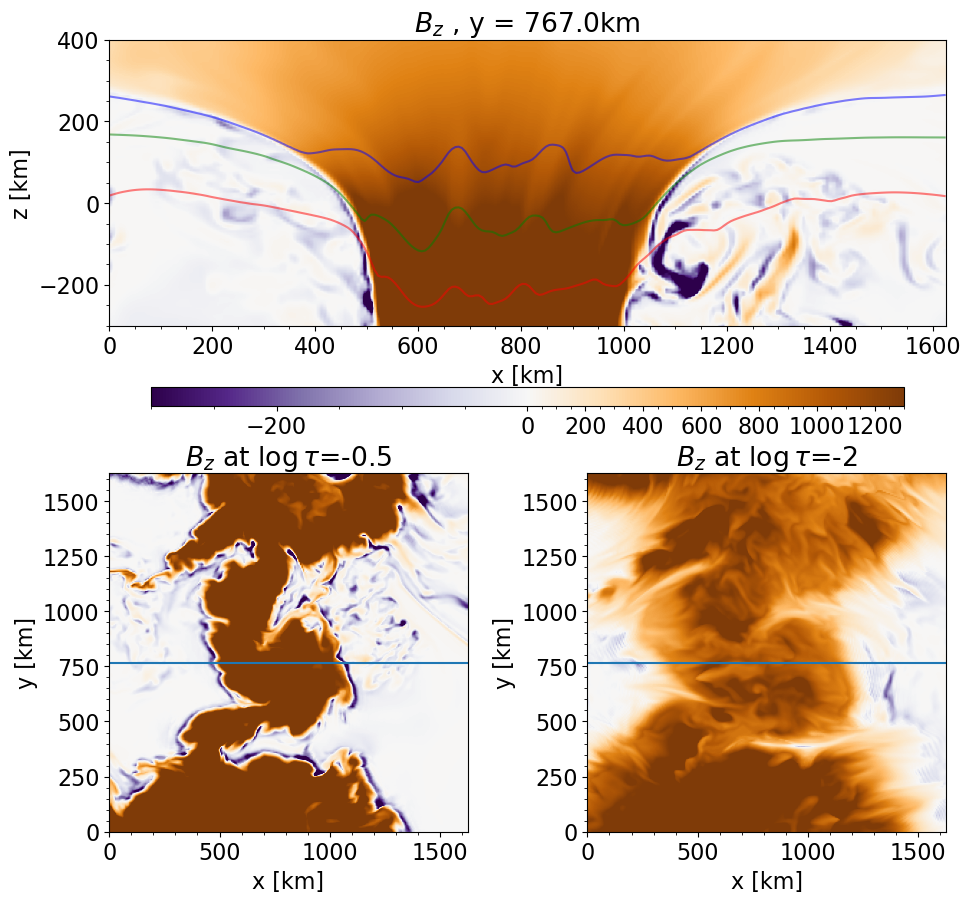

In [ ]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(10,9.5))
gs = gridspec.GridSpec(2,2,hspace=0)
ax1 = fig.add_subplot(gs[0,:])
ax1.imshow(sim.bz[850:1100,768,50:200].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300),extent=[0,250*6.5,-60*6.5,(150-60)*6.5],aspect='auto')
ax1.contour(sim.tau[850:1100,768,50:200].T,levels=['-2','-1','0'],extent=[0,250*6.5,-60*6.5,(150-60)*6.5],colors=['blue','green','red'],alpha=0.5)
ax1.set_ylim([-300,400])
ax1.set_ylabel('z [km]')
ax1.set_xlabel('x [km]')
ax1.set_title(r'$B_z$ , y = '+str((768-650)*6.5)+'km')
ax2 = fig.add_subplot(gs[1,0])
ax2.imshow(Bz[850:1100,650:900,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300),extent=[0,250*6.5,0,250*6.5])
ax2.set_ylabel('y [km]')
ax2.set_xlabel('x [km]')
ax2.axhline((768-650)*6.5)
ax2.set_title(r'$B_z$ at $\log\tau$=-0.5')
ax3 = fig.add_subplot(gs[1,1])
im=ax3.imshow(Bz[850:1100,650:900,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300),extent=[0,250*6.5,0,250*6.5])
ax3.set_ylabel('y [km]')
ax3.set_xlabel('x [km]')
ax3.axhline((768-650)*6.5)
ax3.set_title(r'$B_z$ at $\log\tau$=-2')
cbar=plt.colorbar(im,ax=ax1,location='bottom',shrink=0.9,aspect=40)
cbar.set_ticks([-200,0,200,400,600,800,1000,1200])
plt.tight_layout()
#plt.savefig('Bz_vertical.png',bbox_inches='tight')

## vorticity 
(see plots.ipynb)

## Appendix A


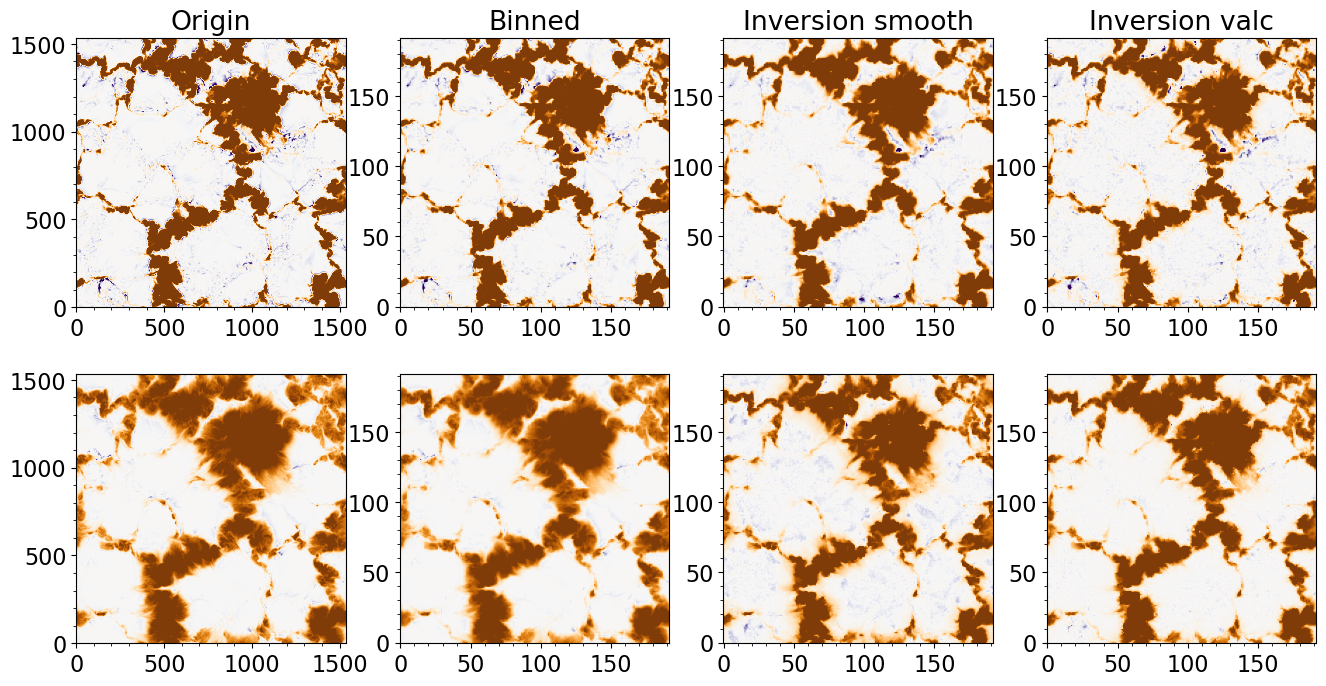

In [302]:
plt.figure(figsize=(16,8))
plt.subplot(241)
plt.imshow(Bz[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.title('Origin')
plt.subplot(245)
plt.imshow(Bz[:,:,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.subplot(242)
plt.imshow(Bz_bin[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.title('Binned')
plt.subplot(246)
plt.imshow(Bz_bin[:,:,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.subplot(243)
plt.imshow(Bz1[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.title('Inversion smooth')
plt.subplot(247)
plt.imshow(Bz1[:,:,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.subplot(244)
plt.imshow(Bz2[:,:,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.title('Inversion valc')
plt.subplot(248)
plt.imshow(Bz2[:,:,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))

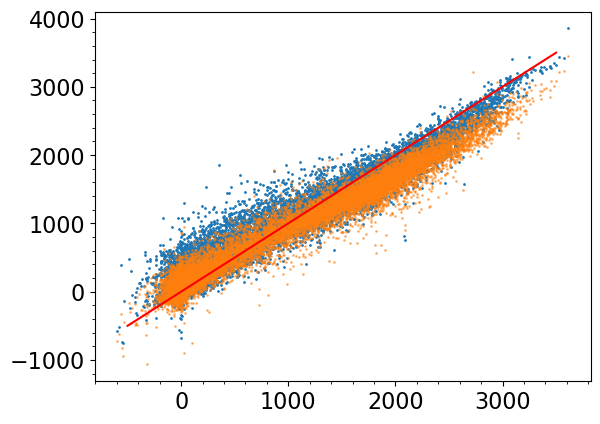

In [ ]:
plt.scatter(Bz_bin[:,:,15].flatten(),Bz1[:,:,15].flatten(),s=1) # inversion with smoothed original atmos
plt.scatter(Bz_bin[:,:,15].flatten(),Bz2[:,:,15].flatten(),s=1,alpha=0.5) # inversion with valc model
plt.plot([-500,3500],[-500,3500],c='r')

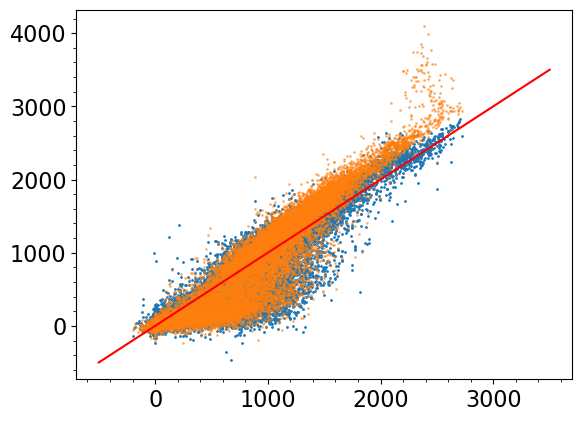

In [310]:
plt.scatter(Bz_bin[:,:,30].flatten(),Bz1[:,:,30].flatten(),s=1) # inversion with smoothed original atmos
plt.scatter(Bz_bin[:,:,30].flatten(),Bz2[:,:,30].flatten(),s=1,alpha=0.5) # inversion with valc model
plt.plot([-500,3500],[-500,3500],c='r')

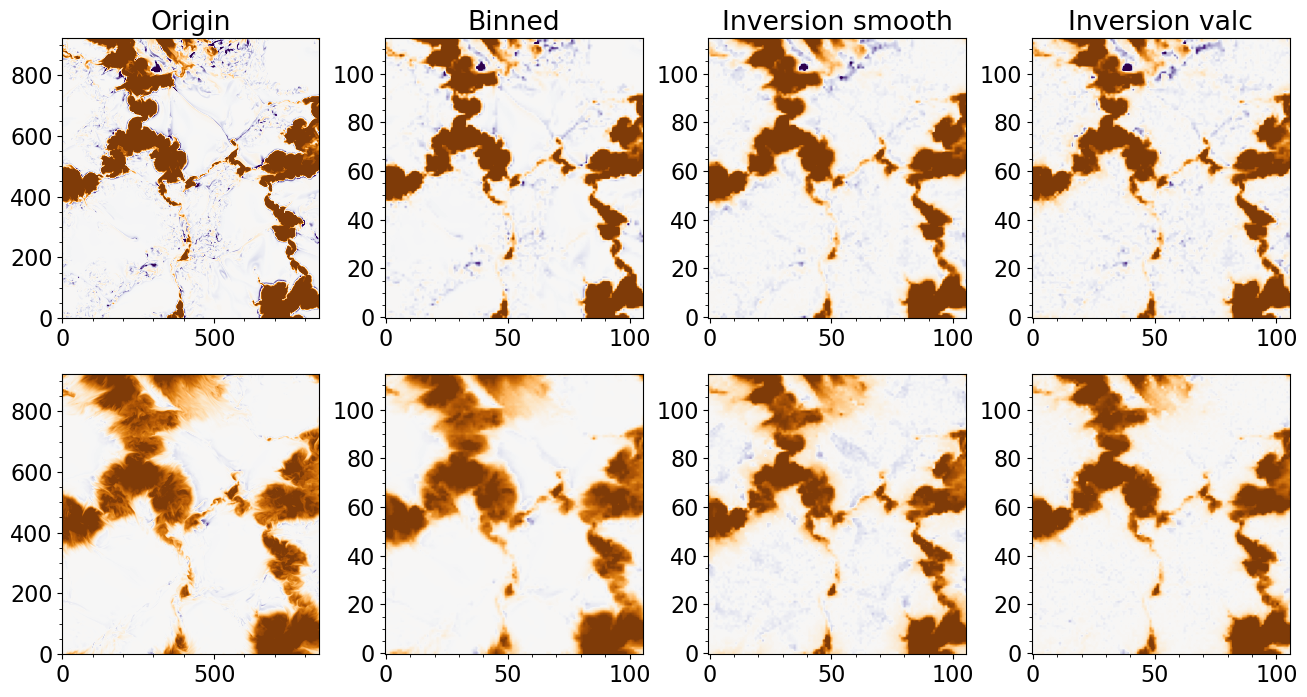

In [308]:
plt.figure(figsize=(16,8))
plt.subplot(241)
plt.imshow(Bz[x1:x2,y1:y2,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.title('Origin')
plt.subplot(245)
plt.imshow(Bz[x1:x2,y1:y2,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.subplot(242)
plt.imshow(Bz_bin[x1//8:x2//8,y1//8:y2//8,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.title('Binned')
plt.subplot(246)
plt.imshow(Bz_bin[x1//8:x2//8,y1//8:y2//8,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.subplot(243)
plt.imshow(Bz1[x1//8:x2//8,y1//8:y2//8,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.title('Inversion smooth')
plt.subplot(247)
plt.imshow(Bz1[x1//8:x2//8,y1//8:y2//8,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.subplot(244)
plt.imshow(Bz2[x1//8:x2//8,y1//8:y2//8,15].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))
plt.title('Inversion valc')
plt.subplot(248)
plt.imshow(Bz2[x1//8:x2//8,y1//8:y2//8,30].T,origin='lower',cmap='PuOr_r',norm=TwoSlopeNorm(vmin=-300,vcenter=0,vmax=1300))

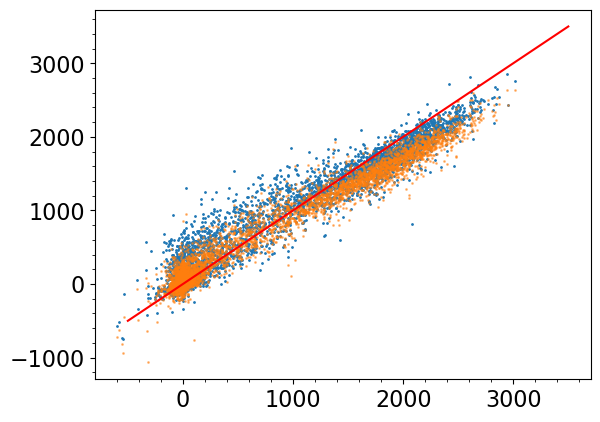

In [309]:
plt.scatter(Bz_bin[x1//8:x2//8,y1//8:y2//8,15].flatten(),Bz1[x1//8:x2//8,y1//8:y2//8,15].flatten(),s=1) # inversion with smoothed original atmos
plt.scatter(Bz_bin[x1//8:x2//8,y1//8:y2//8,15].flatten(),Bz2[x1//8:x2//8,y1//8:y2//8,15].flatten(),s=1,alpha=0.5) # inversion with valc model
plt.plot([-500,3500],[-500,3500],c='r')

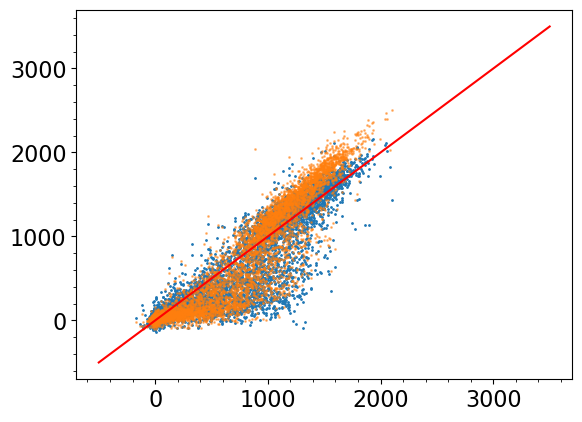

In [314]:
plt.scatter(Bz_bin[x1//8:x2//8,y1//8:y2//8,30].flatten(),Bz1[x1//8:x2//8,y1//8:y2//8,30].flatten(),s=1) # inversion with smoothed original atmos
plt.scatter(Bz_bin[x1//8:x2//8,y1//8:y2//8,30].flatten(),Bz2[x1//8:x2//8,y1//8:y2//8,30].flatten(),s=1,alpha=0.5) # inversion with valc model
plt.plot([-500,3500],[-500,3500],c='r')